# Figure 4: Multiple occluders

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2025-02-12 18:04:43,442::INFO::settings.py::Setting loglevel to INFO
2025-02-12 18:04:43,444::INFO::settings.py::Setting stores to {}
2025-02-12 18:04:43,445::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-02-12 18:04:43,446::INFO::settings.py::Setting database.misc.create_tables to True
2025-02-12 18:04:43,447::INFO::settings.py::Setting enable_python_native_blobs to True
2025-02-12 18:04:43,447::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-02-12 18:04:43,448::INFO::settings.py::Setting database.user to celia
2025-02-12 18:04:43,452::INFO::settings.py::Setting database.password to celia_mathislab
2025-02-12 18:04:43,613::INFO::connection.py::Connected celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


Connecting celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-02-12 18:04:43,713::INFO::table.py::could not log event in table ~log
2025-02-12 18:04:44,132::INFO::table.py::could not log event in table ~log
2025-02-12 18:04:44,132::INFO::table.py::could not log event in table ~log
2025-02-12 18:04:44,680::INFO::table.py::could not log event in table ~log
2025-02-12 18:04:44,680::INFO::table.py::could not log event in table ~log
2025-02-12 18:04:44,826::INFO::table.py::could not log event in table ~log
2025-02-12 18:04:44,826::INFO::table.py::could not log event in table ~log
2025-02-12 18:04:45,233::INFO::table.py::could not log event in table ~log
2025-02-12 18:04:45,233::INFO::table.py::could not log event in table ~log
2025-02-12 18:04:45,574::INFO::table.py::could not log event in table ~log
2025-02-12 18:04:45,574::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils

from statsmodels.stats.anova import AnovaRM 
from scipy.stats import ttest_rel, ttest_ind
style()

save_fig_path =  "notebooks/Paper_figures/Figure_output/"

In [ ]:
multi_occluder = [
                # Mathis lab
                {"dataset": "Nightingale_2024-08-15_1"},
                {"dataset": "Nightingale_2024-08-16_1"},
                {"dataset": "Nightingale_2024-08-21_1"},
                {"dataset": "Nightingale_2024-08-22_1"},
                {"dataset": "Lemming_2024-08-14_1"},
                {"dataset": "Lemming_2024-08-15_1"},
                {"dataset": "Lemming_2024-08-16_1"},
                {"dataset": "Lemming_2024-08-19_1"},
                {"dataset": "Jacana_2024-08-20_1"},
                {"dataset": "Jacana_2024-08-21_1"},
                {"dataset": "Jacana_2024-08-22_1"},
                {"dataset": "Kiwi_2024-08-19_1"},
                {"dataset": "Kiwi_2024-08-20_1"},
                {"dataset": "Kiwi_2024-08-21_1"},
                {'dataset': 'Pheasant_2024-08-23_1'},
                {'dataset': 'Pheasant_2024-08-26_1'},
                {'dataset': 'Pheasant_2024-08-27_2'},
                {'dataset': 'Pheasant_2024-08-28_1'},
                {'dataset': 'Oribi_2024-08-23_1'},
                {'dataset': 'Oribi_2024-08-26_1'},
                {'dataset': 'Oribi_2024-08-27_1'},
                {'dataset': 'Oribi_2024-08-28_1'},
                {'dataset': 'Oribi_2024-08-29_1'},
                # Niell lab
                {"dataset": "J729_2024-12-11_1"},
                {"dataset": "J729_2024-12-12_1"},
                {"dataset": "J729_2024-12-13_1"},
                {"dataset": "J729_2024-12-15_1"}
                ]

In [6]:
def get_all_in_list(data_set_list, training_stage):
    print(training_stage)
    big_df = []
    
    for d in data_set_list:
        split_d = d["dataset"].split("_")
        print(split_d)
        
        offline_kinematics_df = dlc.OfflineKinematics().get_data(key=d, columns = ["head_center_x", "head_center_y", "heading_dir", "head_angle"])
        df = base_analysis.DataFrame().get_data(key=d, 
                                                        columns=[
                                                            'dataset', 'trial', 'aperture',
                                                            'trial_right_choice', 'trial_left_choice',
                                                            'velocity', 'velocity_x', 'velocity_y',
                                                            "reward",
                                                            'norm_y', "iti", "x", "y",
                                                            'trial_init_x', 'trial_init_y',
                                                            "trial_tortuosity", "trial_duration"
        ])
        df["trial_rewarded"] = base_analysis.DataFrame().get_rewarded(key=d)
        
        df = df.join(offline_kinematics_df)
        
        df["mouse_name"] = split_d[0]
        df["date"] = split_d[1]
        df["attempt"] = split_d[2]
        df["training_stage"] = training_stage
        
        big_df.append(df)
    
    big_df =  pd.concat(big_df).reset_index()
    big_df ["session_increment"] = np.array(big_df.groupby("dataset").ngroup()+1)
    big_df = big_df.infer_objects()
    
    return(big_df.reset_index(drop=True))

In [9]:
dfs = []
dual = (vr4mice.Dataset() & f'session_label = "ar_discrim_5_occluders"') & (vr4mice.Collab() & 'idx=3')
dual_list = [{"dataset": x["dataset"]}for x in dual]
if {"dataset": 'J731_2024-12-15_1'} in dual_list:
    dual_list.remove({"dataset": 'J731_2024-12-15_1'})
print(dual_list)
big_df = get_all_in_list(data_set_list = dual_list, training_stage="ar_discrim_occluders")

[{'dataset': 'J729_2024-12-11_1'}, {'dataset': 'J729_2024-12-12_1'}, {'dataset': 'J729_2024-12-13_1'}, {'dataset': 'J729_2024-12-15_1'}]
ar_discrim_occluders
['J729', '2024-12-11', '1']
['J729', '2024-12-12', '1']
['J729', '2024-12-13', '1']
['J729', '2024-12-15', '1']


In [ ]:
big_df = get_all_in_list(data_set_list=multi_occluder, training_stage="multi_occluder")

In [10]:
big_df.to_pickle("big_df_contrast_multi_niell.pkl")

In [21]:
niell_data = pd.read_pickle("big_df_contrast_multi_niell.pkl")
mathis_data = pd.read_pickle("big_df_contrast_multi.pkl")
big_df = pd.concat([niell_data, mathis_data]).reset_index(drop=True)

2025-02-12 18:20:40,489::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 18:20:40,489::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 18:20:40,501::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 18:20:40,501::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 18:20:40,538::INFO::category.py::Using categorical un

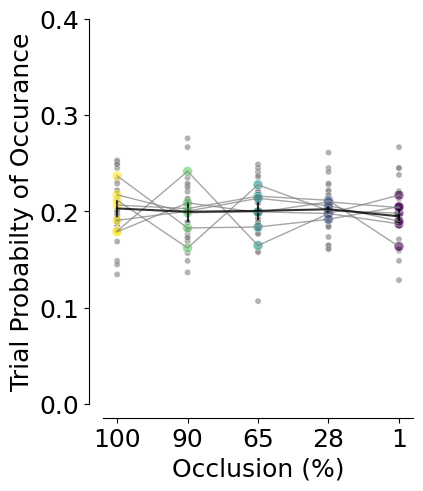

In [22]:
# Occurance of the different conditions
counts = big_df.groupby(["dataset", "mouse_name", "aperture"]).trial.nunique().reset_index(name="trial_count")
total_trials = big_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
    
counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts.sort_values("aperture", inplace=True)
counts ["aperture"] = counts.aperture.astype("str")
    
fig,ax = plt.subplots(1,1, figsize = (4,5))

sns.lineplot(data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(), 
             x="aperture", 
             y="probability", 
             units="mouse_name", 
             estimator=None, 
             ax=ax,
             color="grey", 
             alpha=0.7,
             linewidth=1,
             zorder=3)

sns.scatterplot(data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(), 
                x="aperture", 
                y="probability", 
                hue="aperture", 
                ax=ax,
                palette=plotting.colors_multi_aperture,
                alpha=0.6,
                s=50,
                zorder=2)

sns.scatterplot(data=counts, 
                x="aperture", 
                y="probability", 
                hue="aperture", 
                ax=ax,
                palette = ["grey"] * counts["dataset"].nunique(), 
                alpha=0.6, 
                zorder=1,
                s=20)

sns.lineplot(data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(), 
             x="aperture", 
             y="probability", 
             ax=ax,
             color="black", 
             err_style="bars",
             errorbar="se",  
             alpha=0.8, 
             zorder=4)

#ax.axhline(0.5, linestyle="dashed", color="black", alpha=1)

plt.ylim(0,0.4)
#plt.xlim(-0.5,1.5)
plt.xticks([0,1,2,3,4], ["100", "90", "65", "28", "1"])

plt.xlabel("Occlusion (%)")
plt.ylabel("Trial Probabilty of Occurance")
sns.despine(offset=10)
plt.legend([],[], frameon=False)

plt.savefig(save_fig_path + "multi_occluder_trial_number.svg", transparent=True)

counts = counts.pivot(index = "dataset", columns=["aperture"], values=["probability"]) 

2025-02-12 18:21:01,865::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 18:21:01,865::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 18:21:01,873::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 18:21:01,873::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 18:21:01,969::INFO::category.py::Using categorical un

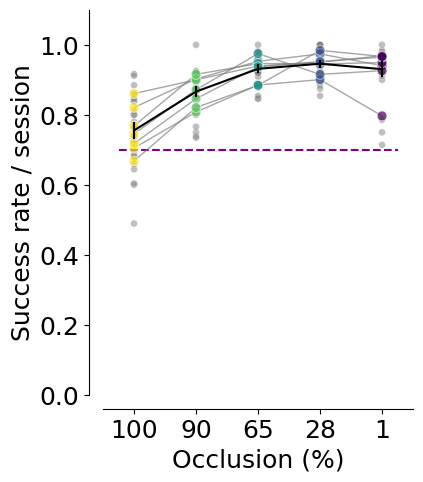

In [23]:
fig,ax = plt.subplots(1,1, figsize = (4,5))
plotting.plot_rewards(df=big_df, ax=ax, alpha=0.5, 
                      per_aperture=True,
                      per_mouse=True,
                      cmap=plotting.colors_multi_aperture)

plt.ylim(0,1.1)
ax.set_xticks([0,1,2,3,4], ["100", "90", "65", "28", "1"])
ax.set_xlabel("Occlusion (%)")
ax.set_ylabel("Success rate / session")
ax.set_xticks([0,1,2,3,4], ["100", "90", "65", "28", "1"])
ax.set_ylim(0,1.1)

plt.legend([],[], frameon=False)

sns.despine(offset=10)

plt.savefig(save_fig_path + "multi_occluder_rewards.svg", transparent=True)

In [24]:
# Filter the data - no iti and only J_shaped trials
big_df = big_df [big_df.iti == 0.0].copy()
j_shaped =  analysis.get_jshaped_trials(big_df)
j_shaped = utils.create_bins(data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y")

mean_mouse = j_shaped.groupby(
    ["dataset", "trial_left_choice", "aperture", "bin_centers"], as_index=False
).mean(numeric_only =True).copy()

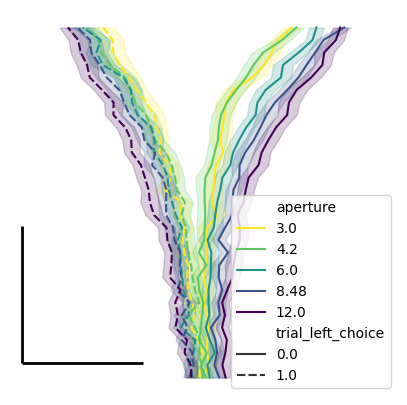

In [25]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
plotting.lineplot_flip_axis(
    data=mean_mouse,
    x=mean_mouse.bin_centers,
    y="x",
    hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice if len(mean_mouse.aperture.unique()) == 2 else plotting.colors_multi_aperture,
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "trial_left_choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-16,16)
plt.vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)
plt.hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)
plt.axis('off')
ax.legend(loc="lower right")
sns.despine(offset = 10)
plt.savefig(save_fig_path + "multi_occluder_mean_trajectories.svg", transparent=True)

In [26]:
j_shaped = utils.create_bins(data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y")
j_shaped = j_shaped
j_shaped["flip_one_side"] = j_shaped["trial_left_choice"].replace([0, 1], [1, -1])
j_shaped ["x_flipped"] = j_shaped.x * j_shaped.flip_one_side
mean_mouse = j_shaped.groupby(
    ["dataset", "trial_left_choice", "aperture", "bin_centers", "trial"], as_index=False
).mean(numeric_only=True).copy()
mean_mouse = mean_mouse.groupby(
    ["dataset", "aperture", "bin_centers"], as_index=False
).mean(numeric_only=True).copy()

In [27]:
print(AnovaRM(data=mean_mouse, depvar='x_flipped', 
              subject='dataset', within=['aperture', "bin_centers"]).fit())

                         Anova
                     F Value   Num DF    Den DF  Pr > F
-------------------------------------------------------
aperture              21.1742   4.0000  104.0000 0.0000
bin_centers          245.2239  28.0000  728.0000 0.0000
aperture:bin_centers   5.7862 112.0000 2912.0000 0.0000



**Interpretation**

Since all p-values are very small (0.0000), we can conclude that both aperture and bin_centers significantly influence x_flipped, and their interaction is also significant. This means that the effect of aperture on x_flipped depends on bin_centers.

<Axes: xlabel='bin_centers', ylabel='x_flipped'>

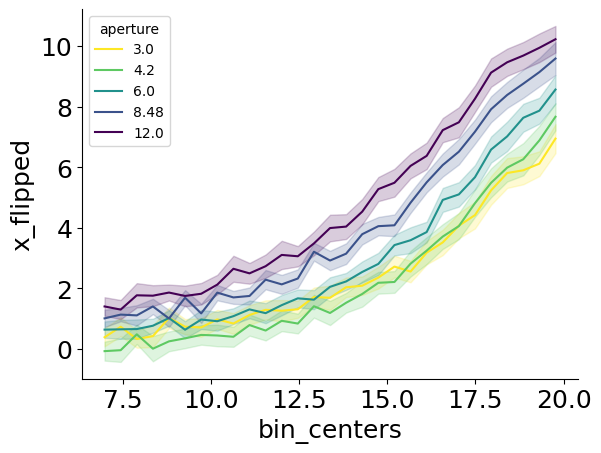

In [28]:
sns.lineplot(data=mean_mouse, x = "bin_centers", y = "x_flipped", hue="aperture", palette=plotting.colors_multi_aperture, errorbar="se", alpha=1)


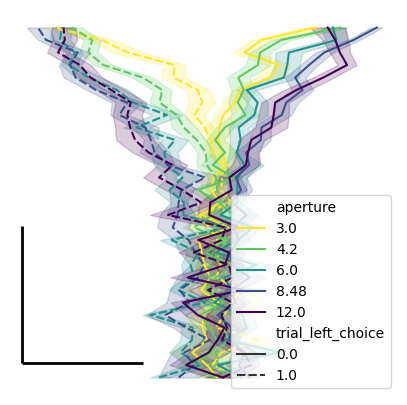

In [29]:
# Example

fig, ax = plt.subplots(1,1,figsize=(5,5))
plotting.lineplot_flip_axis(
    data=j_shaped [j_shaped.dataset ==  "Kiwi_2024-08-19_1"],
    x="bin_centers",
    y="x",
    hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice[::-1] if len(mean_mouse.aperture.unique()) == 2 else plotting.colors_multi_aperture,
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "trial_left_choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-16,16)
plt.vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)

plt.hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)
#plt.arrow(-14, 7.5, 10, 0, head_width=.3, head_length=.5, linewidth=2, color='black', length_includes_head=True)
plt.axis('off')

ax.legend(loc="lower right")
plt.savefig(save_fig_path + "multi_occluder_trajectories_example_session.svg", transparent=True)